# M1A7 — Trabalho Final do Módulo 1: Planejador de Viagens com Tool-Calling

Agente de planejamento de viagens construído com **LangGraph**, estendido com **ferramentas (tools)** que o LLM decide chamar sozinho:

| Tool | O que faz | Fonte |
|------|-----------|-------|
| `calcular_orcamento` | Soma diárias + passagem + extras | Python puro |
| `ver_temperatura` | Clima atual do destino | Busca Tavily |
| `sugerir_restaurantes` | Restaurantes recomendados | Busca Tavily |
| `preco_passagens` | Preço estimado de passagens | Busca Tavily |

**Fluxo do grafo:** `query → search → agent ⇄ tools → feedback`. O nó `agent` usa `bind_tools`: enquanto pedir ferramentas, vai para `tools` e volta; quando finaliza, vai para `feedback` (human-in-the-loop). Se o usuário pedir mudanças, o `feedback` volta para o `agent` no modo revisão (até 3 revisões).

Dual provider (Gemini default / OpenAI) e Tavily, iguais ao M1A4. Requer `TAVILY_API_KEY` no `.env`.

## 1. Setup do ambiente e provider

Carrega o `.env`, escolhe o provider via `LLM_PROVIDER` (default `gemini`) e instancia o modelo com `temperature=0`. As chaves vêm **só** do `.env` — nada hardcoded.

In [1]:
import os
import operator
from typing import TypedDict, Annotated, List

from dotenv import load_dotenv
from pydantic import BaseModel
from IPython.display import Image, display

load_dotenv()

PROVIDER = os.getenv("LLM_PROVIDER", "gemini").lower()
OPENAI_MODEL = "gpt-4o-mini"
GEMINI_MODEL = "gemini-2.5-flash"

assert os.getenv("TAVILY_API_KEY"), "TAVILY_API_KEY ausente no .env (https://tavily.com)"
if PROVIDER == "openai":
    assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY ausente no .env"
    from langchain_openai import ChatOpenAI
    model = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
elif PROVIDER == "gemini":
    assert os.getenv("GOOGLE_API_KEY"), "GOOGLE_API_KEY ausente no .env"
    from langchain_google_genai import ChatGoogleGenerativeAI
    model = ChatGoogleGenerativeAI(model=GEMINI_MODEL, temperature=0)
else:
    raise ValueError(f"LLM_PROVIDER desconhecido: {PROVIDER}")

print(f"Provider ativo: {PROVIDER}")

Provider ativo: gemini


## 2. Ferramentas (tools)

Cada função é decorada com `@tool` — o LangChain gera o schema a partir das type hints e da docstring, e é isso que o LLM enxerga ao decidir qual chamar.

- `calcular_orcamento` é matemática pura.
- As outras três usam uma busca Tavily (helper `_busca`).

`known_actions` é o **dicionário de ferramentas** do agente (`{nome: tool}`), e `model_tools = model.bind_tools(tools)` é o modelo ciente das ferramentas.

In [2]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=3)


def _busca(query: str) -> str:
    """Roda uma busca Tavily e devolve os trechos concatenados."""
    try:
        res = search_tool.invoke(query)
        if isinstance(res, dict):
            if res.get("error"):
                return f"Busca indisponivel: {res['error']}"
            results = res.get("results") or []
        else:
            results = res
        trechos = [r.get("content", "") for r in results]
        return "\n\n".join(t for t in trechos if t) or "Sem resultados."
    except Exception as e:
        return f"Erro na busca: {e}"


@tool
def calcular_orcamento(dias: int, diaria: float, custo_passagem: float = 0.0, extras: float = 0.0) -> str:
    """Calcula o orcamento total de uma viagem.

    dias: numero de dias. diaria: gasto medio por dia (hospedagem + alimentacao).
    custo_passagem: passagem aerea ida e volta. extras: passeios, seguro, etc."""
    hospedagem = dias * diaria
    total = hospedagem + custo_passagem + extras
    return (
        f"Orcamento estimado para {dias} dias:\n"
        f"- Diarias ({dias} x {diaria:.2f}): {hospedagem:.2f}\n"
        f"- Passagem aerea: {custo_passagem:.2f}\n"
        f"- Extras: {extras:.2f}\n"
        f"- TOTAL: {total:.2f}"
    )


@tool
def ver_temperatura(destino: str) -> str:
    """Busca informacoes sobre o clima e a temperatura atual de um destino."""
    return _busca(f"clima e temperatura atual em {destino}")


@tool
def sugerir_restaurantes(destino: str, tipo: str = "") -> str:
    """Sugere restaurantes em um destino. tipo: culinaria desejada (opcional)."""
    return _busca(f"melhores restaurantes {tipo} em {destino}".replace("  ", " "))


@tool
def preco_passagens(destino: str, origem: str = "Sao Paulo") -> str:
    """Busca precos estimados de passagens aereas de uma origem ate o destino."""
    return _busca(f"preco passagem aerea de {origem} para {destino}")


tools = [calcular_orcamento, ver_temperatura, sugerir_restaurantes, preco_passagens]
known_actions = {t.name: t for t in tools}   # dicionario de ferramentas do agente
model_tools = model.bind_tools(tools)
print("Ferramentas disponiveis:", list(known_actions))

Ferramentas disponiveis: ['calcular_orcamento', 'ver_temperatura', 'sugerir_restaurantes', 'preco_passagens']


## 3. Estado do agente

`AgentState` carrega o progresso. Novo em relação ao código base: o canal `messages` guarda a conversa do agente durante o ciclo de tool-calling (semântica de sobrescrita — o nó que escreve devolve a lista completa).

`Queries` é o schema usado por `with_structured_output` para extrair a lista de buscas.

In [3]:
class AgentState(TypedDict):
    task: str
    queries: List[str]
    draft: List[str]
    messages: list
    result: str
    user_feedback: str
    revision_count: int


class Queries(BaseModel):
    queries: List[str]

## 4. Prompts

Três prompts: gerar buscas, montar o roteiro e revisar. Os prompts de roteiro e revisão avisam o modelo de que ele pode chamar as ferramentas quando o pedido envolver orçamento, clima, restaurantes ou passagens.

In [4]:
QUERY_MAKER_PROMPT = """
Voce e um especialista em planejamento de viagens.
Voce recebera um destino de viagem e devera montar uma lista de queries para buscar
informacoes sobre atividades no destino com base no interesse do usuario.

Gere uma lista de 5-8 queries especificas e relevantes para buscar informacoes sobre:
- Atividades relacionadas aos interesses do usuario
- Locais especificos para essas atividades
- Melhores epocas para visitar
- Informacoes praticas (precos, horarios, etc.)

Retorne apenas as queries, uma por linha, sem numeracao.
"""

TOOLS_NOTE = """
Voce tem ferramentas disponiveis e DEVE usa-las quando o pedido exigir:
- calcular_orcamento(dias, diaria, custo_passagem, extras): orcamento total.
- ver_temperatura(destino): clima atual.
- sugerir_restaurantes(destino, tipo): restaurantes.
- preco_passagens(destino, origem): preco de passagens.
Use o preco_passagens para estimar a passagem antes de calcular o orcamento, quando fizer sentido.
"""

RESULT_PROMPT = """
Voce e um especialista em planejamento de viagens.

Com base nas informacoes coletadas, gere um planejamento de viagem completo e personalizado.
Torne o texto amigavel, cativante e envolvente.

Estruture o resultado com:
1. INTRODUCAO - Resumo do destino e interesses
2. ATIVIDADES PRINCIPAIS - Baseadas nos interesses do usuario
3. LOCAIS RECOMENDADOS - Especificos para as atividades
4. DICAS PRATICAS - Informacoes uteis (clima, restaurantes, orcamento, passagens quando pedido)
5. CRONOGRAMA SUGERIDO - Organizacao da viagem
""" + TOOLS_NOTE + """
Informacoes coletadas:
{draft}

Interesses do usuario: {task}

Gere um planejamento completo e detalhado:
"""

REVISION_PROMPT = """
Voce e um especialista em planejamento de viagens.

O usuario forneceu feedback sobre um planejamento. Revise e melhore o planejamento com base
no feedback, usando tambem as informacoes coletadas e as ferramentas disponiveis.

PLANEJAMENTO ATUAL:
{current_result}

FEEDBACK DO USUARIO:
{user_feedback}

INTERESSES ORIGINAIS:
{task}

INFORMACOES COLETADAS:
{draft}
""" + TOOLS_NOTE + """
Mantenha a estrutura organizada e faca as modificacoes necessarias.
Gere um planejamento revisado e melhorado:
"""

## 5. Nós do grafo

- `query_node` / `search_node`: geram as buscas e preenchem o `draft` (contexto base), como no código original.
- `agent_node`: o coração tool-calling. Detecta se é um **turno novo** (início ou entrada em revisão) ou continuação após uma ferramenta:
  - turno novo → monta o prompt (`RESULT_PROMPT`, ou `REVISION_PROMPT` se houver feedback pendente);
  - continuação → segue a conversa com os `ToolMessage`s já anexados.
  Quando o modelo para de pedir ferramentas, grava o texto final em `result`.
- `tools_node`: executa cada `tool_call` via `known_actions` e devolve `ToolMessage`s (imprime cada chamada — é assim que observamos o agente usando as ferramentas).
- `feedback_node`: human-in-the-loop com `input()`.
- `route_after_agent` / `should_continue`: arestas condicionais.

In [5]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


def query_node(state: AgentState):
    """Gera as queries de busca com base no destino e interesses."""
    messages = [SystemMessage(content=QUERY_MAKER_PROMPT), HumanMessage(content=state["task"])]
    response = model.with_structured_output(Queries).invoke(messages)
    return {"queries": response.queries}


def search_node(state: AgentState):
    """Roda as buscas Tavily e acumula o contexto em draft."""
    draft = state.get("draft") or []
    for q in state["queries"]:
        draft.append(_busca(q))
    return {"draft": draft}


def agent_node(state: AgentState):
    """Agente com tool-calling: planeja (ou revisa) e pode chamar ferramentas."""
    msgs = state.get("messages") or []
    last = msgs[-1] if msgs else None
    fresh = (not msgs) or isinstance(last, AIMessage)  # inicio ou entrada de revisao
    if fresh:
        draft = "\n\n".join(state.get("draft") or [])
        fb = state.get("user_feedback")
        if fb and fb not in ("", "Aprovado", "Sair"):
            sys = REVISION_PROMPT.format(
                current_result=state.get("result", ""), user_feedback=fb,
                task=state["task"], draft=draft)
        else:
            sys = RESULT_PROMPT.format(draft=draft, task=state["task"])
        msgs = [SystemMessage(content=sys), HumanMessage(content=state["task"])]
    response = model_tools.invoke(msgs)
    msgs = msgs + [response]
    out = {"messages": msgs}
    if not response.tool_calls:
        out["result"] = response.content
    return out


def tools_node(state: AgentState):
    """Executa as tool_calls pedidas pelo agente."""
    last = state["messages"][-1]
    results = []
    for call in last.tool_calls:
        print(f"  \U0001f527 tool: {call['name']}({call['args']})")
        observation = known_actions[call["name"]].invoke(call["args"])
        results.append(ToolMessage(tool_call_id=call["id"], name=call["name"], content=str(observation)))
    return {"messages": state["messages"] + results}


def feedback_node(state: AgentState):
    """Mostra o plano e coleta o feedback do usuario (human-in-the-loop)."""
    print("\n" + "=" * 60)
    print("\U0001f3af SEU PLANO DE VIAGEM:")
    print("=" * 60)
    print(state["result"])
    print("=" * 60)
    print("\n\U0001f4ac Quer alguma alteracao? Digite sugestoes, ou 'ok' para finalizar, ou 'sair'.")
    feedback = input("\nSua resposta: ").strip()
    rc = state.get("revision_count", 0)
    if feedback.lower() in ("ok", "perfeito", "finalizar", "done"):
        return {"user_feedback": "Aprovado", "revision_count": rc, "messages": []}
    if feedback.lower() in ("sair", "exit", "quit"):
        return {"user_feedback": "Sair", "revision_count": rc, "messages": []}
    # nova sugestao: zera a conversa para o agente recomecar em modo revisao
    return {"user_feedback": feedback, "revision_count": rc + 1, "messages": []}


def route_after_agent(state: AgentState):
    """Se o agente pediu ferramentas, vai para tools; senao, mostra ao usuario."""
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else "feedback"


def should_continue(state: AgentState):
    """Decide se encerra ou volta para revisao."""
    if state["user_feedback"] in ("Aprovado", "Sair"):
        return "end"
    if state.get("revision_count", 0) >= 3:
        print("\n\u26a0\ufe0f  Limite de 3 revisoes atingido. Finalizando...")
        return "end"
    return "revise"

## 6. Construção e visualização do grafo

Monta o `StateGraph`, liga os nós e compila com um `InMemorySaver` (checkpoint que mantém o estado entre as rodadas de feedback através do `thread_id`).

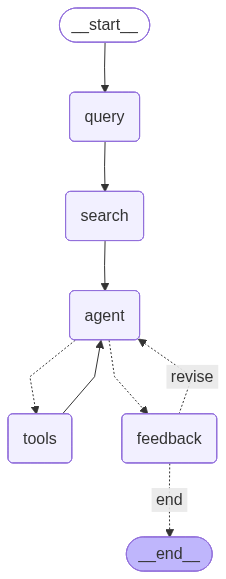

In [7]:
builder = StateGraph(AgentState)
builder.add_node("query", query_node)
builder.add_node("search", search_node)
builder.add_node("agent", agent_node)
builder.add_node("tools", tools_node)
builder.add_node("feedback", feedback_node)

builder.add_edge(START, "query")
builder.add_edge("query", "search")
builder.add_edge("search", "agent")
builder.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "feedback": "feedback"})
builder.add_edge("tools", "agent")
builder.add_conditional_edges("feedback", should_continue, {"revise": "agent", "end": END})

graph = builder.compile(checkpointer=InMemorySaver())

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(visualizacao opcional indisponivel: {e})")
    print(graph.get_graph().draw_ascii())

## 7. Smoke test das ferramentas

Antes de rodar o grafo inteiro, testa as tools isoladamente. Use `.invoke({...})` porque são objetos `@tool` (não funções normais).

In [8]:
print(calcular_orcamento.invoke({"dias": 5, "diaria": 300, "custo_passagem": 2500, "extras": 400}))
print("\n---\n")
print(ver_temperatura.invoke({"destino": "Paris"})[:500])

Orcamento estimado para 5 dias:
- Diarias (5 x 300.00): 1500.00
- Passagem aerea: 2500.00
- Extras: 400.00
- TOTAL: 4400.00

---

A temperatura atual em Paris é de 16°C, com uma temperatura sensação de 9°C. A previsão de hoje mostra uma máxima de 19°C e uma mínima de 14°C, proporcionando

Ilha de França · França  lun. # Tempo Paris. Sol nascente e poente 05:57  21:38. Hoje, está ensolarado durante todo o dia. A temperatura é atualmente de 21 graus e sobe ao longo do dia para 32 graus. ## RadarClima. ## Previsão do tempo Mapas meteorológicos. ## Mapa de vento. ## Tempo 14 dias. ## Mapa de temperatura. Pólen: 7 dias de previ


## 8. Teste end-to-end (com human-in-the-loop)

Roda o planejador completo. Observe nos logs do stream as chamadas `🔧 tool: ...` — é a prova de que o agente está usando as ferramentas. Quando o plano aparecer, digite uma sugestão (ex: *"adicione um dia para pontos históricos"*) para acionar a revisão, ou `ok` para finalizar.

> Consulta multi-etapa de teste: *"Monte um roteiro de 5 dias para Paris, incluindo orçamento total e sugestões de restaurantes."*

In [ ]:
def run_travel_planner(task: str, thread_id: str = "1"):
    print("\U0001f680 Iniciando o Travel Planner...\n" + "=" * 50)
    thread = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "task": task, "queries": [], "draft": [], "messages": [],
        "result": "", "user_feedback": "", "revision_count": 0,
    }
    for step in graph.stream(initial_state, thread):
        if "query" in step:
            print(f"\U0001f50d {len(step['query']['queries'])} queries geradas")
        elif "search" in step:
            print(f"\U0001f4da {len(step['search']['draft'])} fontes coletadas")
        elif "agent" in step and step["agent"].get("result"):
            print("\u2705 Plano gerado/revisado!")
        elif "feedback" in step:
            fb = step["feedback"]["user_feedback"]
            if fb == "Aprovado":
                print("\n\U0001f389 Plano aprovado! Obrigado por usar o Travel Planner!")
            elif fb == "Sair":
                print("\n\U0001f44b Ate a proxima!")
            else:
                print(f"\U0001f504 Revisao #{step['feedback']['revision_count']} solicitada...")


run_travel_planner(
    "Monte um roteiro de 5 dias para China, incluindo orcamento total e sugestoes de restaurantes."
)

🚀 Iniciando o Travel Planner...
🔍 7 queries geradas
📚 7 fontes coletadas
  🔧 tool: preco_passagens({'destino': 'Pequim'})
  🔧 tool: ver_temperatura({'destino': 'Pequim'})
  🔧 tool: ver_temperatura({'destino': 'Xangai'})
  🔧 tool: calcular_orcamento({'dias': 5, 'extras': 500, 'custo_passagem': 7000, 'diaria': 400})
  🔧 tool: sugerir_restaurantes({'destino': 'Pequim', 'tipo': 'chinesa'})
  🔧 tool: sugerir_restaurantes({'destino': 'Xangai', 'tipo': 'chinesa'})
